# Final model · Stage 2 — fairness checks and reason codes

**Starting point:** M3-B-mono + Platt calibration (Stage 1).

- **Part A, fairness:** does the model need `zip_code`? (Rule fixed in the plan: drop it if it adds < 0.002 ROC-AUC.) How are different areas and states treated?
- **Part B, reason codes:** turn SHAP values into plain-language reasons for every applicant.

Validation split only; **test sealed**. Plan: `IMPLEMENTATION_PLAN.md`.

## 1. Setup

In [1]:
import json, os, sys, time, platform
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "modeling").is_dir())
sys.path.insert(0, str(ROOT))
from src.modeling import evaluation as ev
from src.modeling import reason_codes as rc

ON_KAGGLE = Path("/kaggle/input").exists()
if ON_KAGGLE:   # data comes from the private input dataset; everything else uses the repo layout
    data_dir = next(Path("/kaggle/input").rglob("X_train.parquet")).parent
    ev.DATA_DIR, ev.METADATA_PATH = data_dir, data_dir / "metadata_v2.json"

STAGE1 = ROOT / "models" / "final" / "01_selection_calibration" / "results"
RESULTS = ROOT / "models" / "final" / "02_reason_codes_fairness" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
SEED, REF_APPROVAL = 42, 0.70
choice1 = json.loads((STAGE1 / "final_model_choice.json").read_text(encoding="utf-8"))
cal1 = json.loads((STAGE1 / "calibrator.json").read_text(encoding="utf-8"))
m3 = json.loads((ROOT / "models" / "M3_lightgbm" / "results" / "m3_metrics.json").read_text(encoding="utf-8"))
print("Running on:", "Kaggle" if ON_KAGGLE else "local machine")
print("Python", platform.python_version(), "| scikit-learn", sklearn.__version__, "| lightgbm", lgb.__version__, "| cores", os.cpu_count())
print("Stage 1 final model:", choice1["chosen_model"], "| calibration:", cal1["method"])

Running on: Kaggle
Python 3.13.15 | scikit-learn 1.6.1 | lightgbm 4.6.0 | cores 4
Stage 1 final model: M3-B-mono | calibration: platt


## 2. Data

In [2]:
X_train, y_train_frame = ev.load_split("train")
X_val, y_val_frame = ev.load_split("validation")
y_train = y_train_frame["target"].astype(int).to_numpy()
y_val = y_val_frame["target"].astype(int).to_numpy()
features = choice1["features"]
print(f"train {X_train.shape} | validation {X_val.shape} | final model features: {len(features)}")

train (388124, 190) | validation (162745, 190) | final model features: 147


# Part A — Fairness
## 3. Zip-code ablation: three models trained the same way on this machine
Same recipe as M3-B-mono: M3's chosen parameters, learning rate 0.02, monotonic constraints, early stopping on validation AUC. Comparing three local fits keeps the comparison fair (same machine, same LightGBM version).

In [3]:
BASE = dict(objective="binary", metric=["auc", "binary_logloss"], boosting_type="gbdt", bagging_freq=1, seed=SEED,
            deterministic=True, force_col_wise=True, num_threads=os.cpu_count(), verbosity=-1, feature_pre_filter=False)
PARAMS = {**m3["chosen"]["B"], "learning_rate": m3["final_learning_rate"]["B"], "monotone_constraints_method": "advanced"}
MONOTONE = choice1["monotone_constraints"]

def fit(cols):
    dtrain = lgb.Dataset(X_train[cols], label=y_train, params={"feature_pre_filter": False})
    dval = lgb.Dataset(X_val[cols], label=y_val, reference=dtrain)
    params = {**BASE, **PARAMS, "monotone_constraints": [MONOTONE.get(c, 0) for c in cols]}
    start = time.time()
    booster = lgb.train(params, dtrain, num_boost_round=5000, valid_sets=[dval], valid_names=["validation"],
                        callbacks=[lgb.early_stopping(100, first_metric_only=True, verbose=False)])
    booster.free_dataset()   # release the training Dataset held by the booster (memory)
    return booster, time.time() - start

variants = {
    "full (147 features)": features,
    "without zip_code": [c for c in features if c != "zip_code"],
    "without zip_code and state": [c for c in features if c != "zip_code" and not c.startswith("addr_state_")],
}
fits, raw_val, ablation = {}, {}, []
for name, cols in variants.items():
    booster, secs = fit(cols)
    fits[name] = booster
    raw_val[name] = booster.predict(X_val[cols], num_iteration=booster.best_iteration)
    card = ev.report_card(y_val, raw_val[name])
    ablation.append({"model": name, "features": len(cols), "rounds": booster.best_iteration, "roc_auc": card["roc_auc"],
                     "ks": card["ks"], "brier": card["brier"], "log_loss": card["log_loss"], "minutes": round(secs / 60, 1)})
    print(f"{name}: ROC-AUC {card['roc_auc']:.4f} ({booster.best_iteration} rounds, {secs / 60:.1f} min)")
ablation = pd.DataFrame(ablation).set_index("model")
kaggle_auc = choice1["validation_roc_auc"]["B-mono"]
print(f"\nReference: the Kaggle-trained M3-B-mono scored {kaggle_auc:.4f} (local full refit: {ablation.iloc[0]['roc_auc']:.4f})")
ablation.round(4)

full (147 features): ROC-AUC 0.7354 (1853 rounds, 2.0 min)
without zip_code: ROC-AUC 0.7351 (1931 rounds, 2.1 min)
without zip_code and state: ROC-AUC 0.7330 (1513 rounds, 1.7 min)

Reference: the Kaggle-trained M3-B-mono scored 0.7354 (local full refit: 0.7354)


,features,rounds,roc_auc,ks,brier,log_loss,minutes
model,,,,,,,
full (147 features),147,1853,0.7354,0.3400,0.1428,0.4467,2.0
without zip_code,146,1931,0.7351,0.3404,0.1428,0.4469,2.1
without zip_code and state,99,1513,0.7330,0.3365,0.1432,0.4480,1.7


### Decision (rule fixed in the plan)
Drop `zip_code` if it adds less than **0.002** ROC-AUC.

In [4]:
zip_gain = ablation.loc["full (147 features)", "roc_auc"] - ablation.loc["without zip_code", "roc_auc"]
geo_gain = ablation.loc["full (147 features)", "roc_auc"] - ablation.loc["without zip_code and state", "roc_auc"]
drop_zip = zip_gain < 0.002
print(f"zip_code adds {zip_gain:+.4f} ROC-AUC; all geography adds {geo_gain:+.4f}")
print("Decision:", "DROP zip_code (gain below 0.002)" if drop_zip else "KEEP zip_code (gain at least 0.002)")

zip_code adds +0.0004 ROC-AUC; all geography adds +0.0024
Decision: DROP zip_code (gain below 0.002)


## 4. Who is affected by zip codes?
Applicants are split into 5 equal groups by their area's historical default rate (the target-encoded `zip_code` value). Under a reference policy (approve the safest 70% of applicants; a diagnostic only, real thresholds come in Stage 3), we compare approval rates with and without `zip_code`.

In [5]:
zip_group = pd.qcut(X_val["zip_code"], 5, labels=["1 lowest-risk areas", "2", "3", "4", "5 highest-risk areas"])
def approve(p):
    return p <= np.quantile(p, REF_APPROVAL)
with_zip, without_zip = approve(raw_val["full (147 features)"]), approve(raw_val["without zip_code"])
zip_table = pd.DataFrame({
    "loans": pd.Series(y_val).groupby(zip_group.values, observed=False).size(),
    "actual default rate": pd.Series(y_val).groupby(zip_group.values, observed=False).mean(),
    "approval rate with zip": pd.Series(with_zip).groupby(zip_group.values, observed=False).mean(),
    "approval rate without zip": pd.Series(without_zip).groupby(zip_group.values, observed=False).mean(),
})
zip_table["change (pts)"] = (zip_table["approval rate without zip"] - zip_table["approval rate with zip"]) * 100
flips = (with_zip != without_zip)
print(f"Decisions that flip when zip_code is removed: {flips.sum():,} of {len(flips):,} ({flips.mean():.2%})")
zip_table.round(4)

Decisions that flip when zip_code is removed: 4,930 of 162,745 (3.03%)


,loans,actual default rate,approval rate with zip,approval rate without zip,change (pts)
1 lowest-risk areas,34182,0.1697,0.7816,0.7535,-2.8085
2,31645,0.1959,0.7207,0.7230,0.2307
3,32565,0.2056,0.6963,0.7012,0.4883
4,31853,0.2145,0.6698,0.6706,0.0753
5 highest-risk areas,32500,0.2336,0.6273,0.6490,2.1662


## 5. Final model of this stage
If `zip_code` is dropped, the no-zip model is recalibrated with the same out-of-fold Platt procedure as Stage 1, and its monotonicity is re-verified.

In [6]:
def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def platt_oof(p_raw):
    oof = np.zeros_like(p_raw)
    for fit_idx, out_idx in StratifiedKFold(5, shuffle=True, random_state=SEED).split(p_raw, y_val):
        lr = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_raw[fit_idx]).reshape(-1, 1), y_val[fit_idx])
        oof[out_idx] = lr.predict_proba(logit(p_raw[out_idx]).reshape(-1, 1))[:, 1]
    full = LogisticRegression(C=1e6, max_iter=1000).fit(logit(p_raw).reshape(-1, 1), y_val)
    return oof, {"method": "platt", "formula": "PD_cal = 1 / (1 + exp(-(a * logit(PD_raw) + b)))",
                 "a": float(full.coef_[0, 0]), "b": float(full.intercept_[0])}

def sweep_violations(booster, cols, n=1000):
    sample = X_val.iloc[np.random.default_rng(SEED).choice(len(X_val), n, replace=False)][cols].reset_index(drop=True)
    total = 0
    for feature, direction in MONOTONE.items():
        values = np.unique(np.quantile(X_val[feature], np.linspace(0.01, 0.99, 25)))
        curves = np.column_stack([booster.predict(sample.assign(**{feature: v})) for v in values])
        total += int(((np.diff(curves, axis=1) * direction) < -1e-9).any(axis=1).sum())
    return total

if drop_zip:
    final_name, final_cols = "M3-B-mono-nozip", variants["without zip_code"]
    final_booster = fits["without zip_code"]
    p_raw = raw_val["without zip_code"]
    p_oof, calibrator = platt_oof(p_raw)
    violations = sweep_violations(final_booster, final_cols)
    final_booster.save_model(str(RESULTS / "final_model.txt"), num_iteration=final_booster.best_iteration)
    model_file = "models/final/02_reason_codes_fairness/results/final_model.txt"
    calibrator_file = "models/final/02_reason_codes_fairness/results/calibrator.json"
    (RESULTS / "calibrator.json").write_text(json.dumps({**calibrator, "fitted_on": "validation split (2015 H1)", "model": final_name}, indent=2), encoding="utf-8")
else:
    final_name, final_cols = choice1["chosen_model"], features
    final_booster = lgb.Booster(model_file=str(ROOT / choice1["model_file"]))
    s1 = pd.read_parquet(STAGE1 / "f1_validation_pd.parquet")
    p_raw, p_oof, calibrator = s1["pd_raw"].to_numpy(), s1["pd_calibrated_oof"].to_numpy(), cal1
    violations = choice1["monotonicity_violations"]["B-mono"]
    model_file, calibrator_file = choice1["model_file"], choice1["calibrator_file"]

def calibrate(p):
    return 1 / (1 + np.exp(-(calibrator["a"] * logit(p) + calibrator["b"])))
p_cal = calibrate(p_raw)
card_final = ev.report_card(y_val, p_oof)
print(f"Final model: {final_name} | {len(final_cols)} features | monotonicity violations: {violations}")
print(f"Calibrator: a={calibrator['a']:.4f}, b={calibrator['b']:.4f} | out-of-fold: ROC-AUC {card_final['roc_auc']:.4f}, "
      f"Brier {card_final['brier']:.5f}, mean PD {card_final['mean_pd']:.2%} vs actual {card_final['default_rate']:.2%}")

Final model: M3-B-mono-nozip | 146 features | monotonicity violations: 0
Calibrator: a=1.0386, b=0.1685 | out-of-fold: ROC-AUC 0.7351, Brier 0.14244, mean PD 20.35% vs actual 20.35%


## 6. State-level check on the final model
For every state with at least 1,000 validation loans. **Fairness criterion:** the same PD should mean the same risk everywhere, so the calibration gap (mean PD − actual default rate, using out-of-fold calibrated PDs) should be small in every state. Flag: beyond ±2 percentage points.

33 states with >= 1,000 loans cover 95.1% of validation loans
Calibration gap range: -2.76 to +2.76 points; flagged (beyond +/-2): ['LA', 'TN', 'OR']
ROC-AUC range across states: 0.690 to 0.751


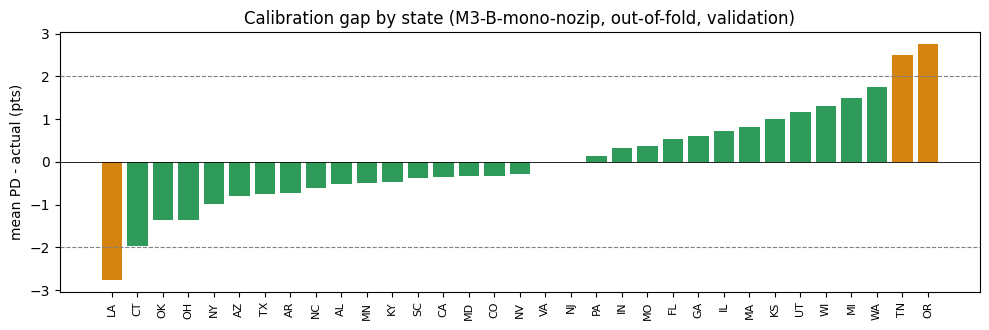

,state,loans,actual_default_rate,mean_pd,calibration_gap_pts,roc_auc,approval_rate,bad_rate_among_approved,flag
12,LA,1998,0.2432,0.2156,-2.7631,0.7271,0.6722,0.1631,True
5,CT,2244,0.1992,0.1795,-1.9672,0.7305,0.7598,0.1408,False
23,OK,1550,0.2432,0.2297,-1.3547,0.7498,0.6394,0.1382,False
22,OH,5431,0.2257,0.2123,-1.3466,0.7354,0.6774,0.1416,False
21,NY,12801,0.2289,0.2191,-0.9739,0.7331,0.6625,0.1413,False
2,AZ,3725,0.2110,0.2030,-0.8011,0.7260,0.7015,0.1378,False
28,TX,13213,0.2001,0.1926,-0.7461,0.7276,0.7311,0.1336,False
1,AR,1120,0.2393,0.2321,-0.7160,0.6902,0.6304,0.1629,False
18,NC,4804,0.2188,0.2127,-0.6120,0.7192,0.6726,0.1405,False
0,AL,2025,0.2464,0.2413,-0.5118,0.7448,0.5990,0.1369,False


In [7]:
state_cols = [c for c in X_val.columns if c.startswith("addr_state_")]
state = X_val[state_cols].idxmax(axis=1).str.replace("addr_state_", "", regex=False).replace("infrequent_sklearn", "other")
cut = np.quantile(p_oof, REF_APPROVAL)
frame = pd.DataFrame({"state": state.values, "y": y_val, "p": p_oof, "approved": p_oof <= cut})
rows = []
for st, g in frame.groupby("state"):
    if len(g) < 1000:
        continue
    rows.append({"state": st, "loans": len(g), "actual_default_rate": g["y"].mean(), "mean_pd": g["p"].mean(),
                 "calibration_gap_pts": (g["p"].mean() - g["y"].mean()) * 100,
                 "roc_auc": roc_auc_score(g["y"], g["p"]), "approval_rate": g["approved"].mean(),
                 "bad_rate_among_approved": g.loc[g["approved"], "y"].mean()})
states = pd.DataFrame(rows).sort_values("calibration_gap_pts")
states["flag"] = states["calibration_gap_pts"].abs() > 2
print(f"{len(states)} states with >= 1,000 loans cover {states['loans'].sum() / len(frame):.1%} of validation loans")
print(f"Calibration gap range: {states['calibration_gap_pts'].min():+.2f} to {states['calibration_gap_pts'].max():+.2f} points; "
      f"flagged (beyond +/-2): {states.loc[states['flag'], 'state'].tolist()}")
print(f"ROC-AUC range across states: {states['roc_auc'].min():.3f} to {states['roc_auc'].max():.3f}")

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(states["state"], states["calibration_gap_pts"], color=np.where(states["flag"], "#d4840f", "#2e9b5b"))
for y in (-2, 2):
    ax.axhline(y, ls="--", color="grey", lw=0.8)
ax.axhline(0, color="black", lw=0.6)
ax.set_ylabel("mean PD - actual (pts)"); ax.set_title(f"Calibration gap by state ({final_name}, out-of-fold, validation)")
plt.xticks(rotation=90, fontsize=8); plt.tight_layout(); plt.savefig(RESULTS / "f2_state_calibration.png", dpi=150); plt.show()
states.round(4)

# Part B — Reason codes
## 7. SHAP values for every validation loan (final model)
The check: base value + sum of contributions must equal the model's raw log-odds for every loan.

SHAP matrix (162745, 147); max |base + sum(SHAP) - log-odds| = 3.33e-14
146 columns grouped into 65 concepts


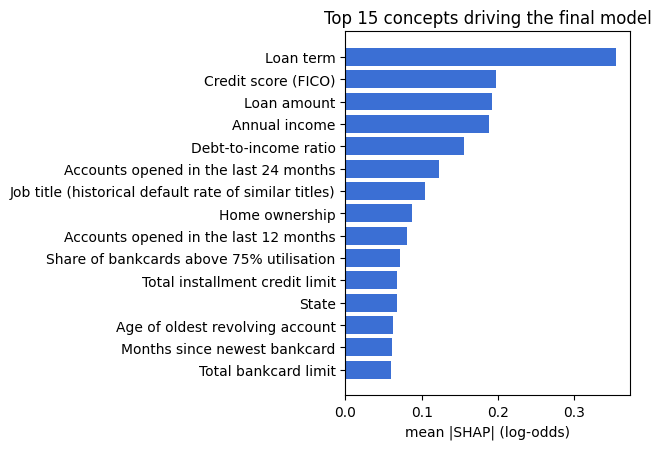

Loan term                                                0.3550
Credit score (FICO)                                      0.1969
Loan amount                                              0.1924
Annual income                                            0.1877
Debt-to-income ratio                                     0.1549
Accounts opened in the last 24 months                    0.1228
Job title (historical default rate of similar titles)    0.1040
Home ownership                                           0.0873
Accounts opened in the last 12 months                    0.0803
Share of bankcards above 75% utilisation                 0.0710
Total installment credit limit                           0.0679
State                                                    0.0679
Age of oldest revolving account                          0.0630
Months since newest bankcard                             0.0613
Total bankcard limit                                     0.0601
dtype: float64

In [8]:
contrib = final_booster.predict(X_val[final_cols], pred_contrib=True)
raw_logodds = final_booster.predict(X_val[final_cols], raw_score=True)
additivity = np.abs(contrib.sum(axis=1) - raw_logodds).max()
print(f"SHAP matrix {contrib.shape}; max |base + sum(SHAP) - log-odds| = {additivity:.2e}")
concepts = rc.concept_shap(contrib, final_cols)
print(f"{len(final_cols)} columns grouped into {concepts.shape[1]} concepts")
global_imp = concepts.abs().mean().sort_values(ascending=False)
top = global_imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.barh([rc.label_of(c) for c in top.index], top.values, color="#3b6fd4")
ax.set_xlabel("mean |SHAP| (log-odds)"); ax.set_title("Top 15 concepts driving the final model"); plt.tight_layout()
plt.savefig(RESULTS / "f2_concept_importance.png", dpi=150); plt.show()
global_imp.head(15).rename(index=rc.label_of).round(4)

## 8. Which reasons would declined applicants actually see?
For the riskiest 30% of applicants (those a 70%-approval policy would decline), count how often each concept is among their **top 4 risk-raising reasons**.

In [9]:
risky = np.flatnonzero(p_oof > cut)
vals = concepts.to_numpy()[risky]
order = np.argsort(-vals, axis=1)[:, :4]
names = concepts.columns.to_numpy()
top4 = [names[o][vals[i, o] > 0] for i, o in enumerate(order)]
counts = pd.Series([c for row in top4 for c in row]).value_counts()
reason_freq = pd.DataFrame({"reason": [rc.label_of(c) for c in counts.index], "concept": counts.index,
                            "share_of_declined_applicants": counts.values / len(risky)})
print(f"Declined under the reference policy: {len(risky):,} applicants; reasons per applicant: "
      f"{np.mean([len(r) for r in top4]):.2f} on average")
reason_freq.head(15).round(3)

Declined under the reference policy: 48,824 applicants; reasons per applicant: 4.00 on average


,reason,concept,share_of_declined_applicants
0,Loan term,term_months,0.596
1,Credit score (FICO),fico_range_low,0.558
2,Debt-to-income ratio,dti,0.433
3,Annual income,annual_inc,0.357
4,Accounts opened in the last 24 months,acc_open_past_24mths,0.344
5,Loan amount,loan_amnt,0.337
6,Job title (historical default rate of similar ...,emp_title,0.282
7,Accounts opened in the last 12 months,num_tl_op_past_12m,0.180
8,Age of oldest revolving account,mo_sin_old_rev_tl_op,0.101
9,Total bankcard limit,total_bc_limit,0.087


## 9. Worked examples: low, medium and high risk applicants

In [10]:
examples = []
for label, q in (("low risk", 0.10), ("medium risk", 0.50), ("high risk", 0.95)):
    i = int(np.argmin(np.abs(p_cal - np.quantile(p_cal, q))))
    out = rc.explain(concepts.iloc[i], X_val[final_cols].iloc[i])
    print(f"\n=== {label}: calibrated PD {p_cal[i]:.1%} (actually defaulted: {bool(y_val[i])}) ===")
    print("  Raised risk:"); [print(f"    + {r['reason']}  ({r['shap_log_odds']:+.3f})") for r in out["risk_factors"]]
    print("  Lowered risk:"); [print(f"    - {r['reason']}  ({r['shap_log_odds']:+.3f})") for r in out["protective_factors"]]
    for kind in ("risk_factors", "protective_factors"):
        for r in out[kind]:
            examples.append({"example": label, "pd_calibrated": p_cal[i], "defaulted": int(y_val[i]),
                             "type": "raises risk" if kind == "risk_factors" else "lowers risk", **r})
examples = pd.DataFrame(examples)


=== low risk: calibrated PD 5.5% (actually defaulted: False) ===
  Raised risk:
    + Loan amount: $24,000  (+0.216)
    + Months since last delinquency: 9 months  (+0.116)
    + Delinquencies in the last 2 years: 3  (+0.116)
    + Months since last bankcard delinquency: 9 months  (+0.105)
  Lowered risk:
    - Annual income: $160,000  (-0.337)
    - Loan term: 36 months  (-0.260)

=== medium risk: calibrated PD 16.9% (actually defaulted: False) ===
  Raised risk:
    + Annual income: $40,587  (+0.277)
    + Debt-to-income ratio: 32.8%  (+0.227)
    + State: TN  (+0.103)
    + Revolving credit utilisation: 91.5%  (+0.095)
  Lowered risk:
    - Loan term: 36 months  (-0.227)
    - Accounts opened in the last 24 months: 2  (-0.160)

=== high risk: calibrated PD 49.1% (actually defaulted: True) ===
  Raised risk:
    + Loan term: 60 months  (+0.651)
    + Debt-to-income ratio: 37.0%  (+0.542)
    + Annual income: $28,800  (+0.415)
    + Accounts opened in the last 12 months: 4  (+0.128)


## 10. Save results

In [11]:
ablation.reset_index().to_csv(RESULTS / "f2_zip_ablation.csv", index=False)
zip_table.reset_index(names="area_group").to_csv(RESULTS / "f2_zip_groups.csv", index=False)
states.to_csv(RESULTS / "f2_states.csv", index=False)
reason_freq.to_csv(RESULTS / "f2_reason_frequency.csv", index=False)
examples.to_csv(RESULTS / "f2_examples.csv", index=False)
global_imp.rename("mean_abs_shap").rename_axis("concept").reset_index().assign(label=lambda d: d.concept.map(rc.label_of)).to_csv(
    RESULTS / "f2_concept_importance.csv", index=False)
choice2 = {**{k: v for k, v in choice1.items() if k not in ("features",)},
           "stage": 2, "chosen_model": final_name, "model_file": model_file, "calibrator_file": calibrator_file,
           "zip_code_decision": {"rule": "drop zip_code if it adds < 0.002 ROC-AUC", "zip_gain": zip_gain,
                                 "geography_gain": geo_gain, "dropped": bool(drop_zip),
                                 "decision_flips_without_zip": int(flips.sum())},
           "monotonicity_violations_final": int(violations), "n_features": len(final_cols), "features": final_cols,
           "validation_oof": {k: card_final[k] for k in ("roc_auc", "brier", "log_loss", "mean_pd", "default_rate")},
           "environment": {"python": platform.python_version(), "scikit_learn": sklearn.__version__, "lightgbm": lgb.__version__,
                           "platform": "Kaggle CPU notebook" if ON_KAGGLE else "local"},
           "test_split": "sealed"}
(RESULTS / "final_model_choice.json").write_text(json.dumps(choice2, indent=2), encoding="utf-8")
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['calibrator.json', 'f2_concept_importance.csv', 'f2_concept_importance.png', 'f2_examples.csv', 'f2_reason_frequency.csv', 'f2_state_calibration.png', 'f2_states.csv', 'f2_zip_ablation.csv', 'f2_zip_groups.csv', 'final_model.txt', 'final_model_choice.json']


## 11. Conclusion

In [12]:
print(f"zip_code: adds {zip_gain:+.4f} ROC-AUC -> {'dropped' if drop_zip else 'kept'}; "
      f"{flips.mean():.2%} of decisions would change without it.")
print(f"Final model after Stage 2: {final_name} ({len(final_cols)} features), out-of-fold ROC-AUC {card_final['roc_auc']:.4f}")
print(f"States: calibration gaps {states['calibration_gap_pts'].min():+.2f} to {states['calibration_gap_pts'].max():+.2f} pts; "
      f"flagged: {states.loc[states['flag'], 'state'].tolist() or 'none'}")
print(f"Most common decline reason: {reason_freq.iloc[0]['reason']} ({reason_freq.iloc[0]['share_of_declined_applicants']:.0%} of declined applicants)")
print("Next: Stage 3, the decision layer. Test split still sealed.")

zip_code: adds +0.0004 ROC-AUC -> dropped; 3.03% of decisions would change without it.
Final model after Stage 2: M3-B-mono-nozip (146 features), out-of-fold ROC-AUC 0.7351
States: calibration gaps -2.76 to +2.76 pts; flagged: ['LA', 'TN', 'OR']
Most common decline reason: Loan term (60% of declined applicants)
Next: Stage 3, the decision layer. Test split still sealed.
